<a href="https://colab.research.google.com/github/fxrdhan/ML_scikit-learn_Cookbook_O-Reilly/blob/main/Chapter_04_Distance_Metrics_and_Nearest_Neighbors/Chapter_04_Distance_Metrics_and_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Building Models with Distance Metrics and Nearest Neighbors

| | |
|---|---|
| **Book** | *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing, 2025) |
| **Library version targeted by the book** | scikit-learn 1.5 |
| **Version used to run this notebook** | scikit-learn 1.9.1 on Python 3.12 (printed by the setup cell) |
| **What this notebook contains** | reproduction of every code listing in the chapter and of the official exercise solutions, chapter and recipe summaries, theoretical deep-dives, and extra experiments |

## Chapter overview

A young child can tell a Toyota from a cheetah, and can also see what a cheetah and a puma have in common. Classifying a new object by its **similarity to objects whose class is already known** is the idea behind some of the simplest machine learning models. Chapter 4 makes "similarity" precise with **distance metrics** and builds models on it with **k-nearest neighbors (KNN)**. It shows how to:

* measure distance with the **Euclidean, Manhattan and Minkowski** metrics;
* train a **KNN classifier** and understand its three ingredients: the number of neighbours $k$, the distance and the vote;
* compare **distance metrics** on datasets with different structure;
* **tune** KNN's hyperparameters with grid search;
* **evaluate** a KNN model with cross-validation, learning curves, a confusion matrix and a classification report;
* practise with three exercises: building, tuning and evaluating KNN classifiers.

### Recipes in this chapter

| # | Recipe | Code in the book | What this notebook adds |
|---|---|---|---|
| 1 | Introduction to distance metrics | No | The metric axioms, the Minkowski family and its unit balls, why $p < 1$ is not a metric, cosine, Hamming and Mahalanobis distances |
| 2 | Understanding KNNs | Yes, 2 listings | The KNN rule and the Cover–Hart bound, decision boundaries for different $k$, choosing $k$ with repeated cross-validation, KNN regression |
| 3 | Distance metrics overview | Yes, 2 listings | Why "minkowski" equals "euclidean" here, a fair comparison over 50 datasets, ties on the checkerboard grid, metrics on real data |
| 4 | Hyperparameter tuning in KNN | Yes, 1 listing | Ties in the grid, randomized search, nested cross-validation, the optimism of `best_score_` |
| 5 | Evaluating KNN performance | Yes, 2 listings | Every metric of the report computed by hand, reading the learning curve, KNN on imbalanced data |
| 6 | Practical exercises with KNN models | Official solutions | What scaling does to exercise 1, one split versus cross-validation, other neighbour-based classifiers |

### How to read this notebook

Every recipe has the same structure:

1. **Summary** — what the book says, condensed.
2. **Theory** — the ideas behind it: math, algorithms and design reasoning.
3. **Book code** — the listing reproduced from the book (page numbers refer to the printed edition), followed by an **output analysis**.
4. **Extra** — experiments written for this notebook to make the theory concrete. They are *not* part of the book.

Every code cell starts with a label comment: `# BOOK CODE` for a listing reproduced from the book, `# EXTRA` for code written for this notebook.

---
## 0. Setup

Every dataset in this chapter ships with scikit-learn (`load_iris`, `load_breast_cancer`, `load_digits`) or is generated with a fixed seed, so the notebook runs offline. The book's evaluation recipe also uses **seaborn** for its confusion-matrix heatmap (`pip install seaborn` if the import fails). The setup cell prints the library versions, fixes a global seed and defines the plotting style used by the extra figures (the book's own listings keep their original colours).

In [1]:
import platform
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
import sklearn
from matplotlib.colors import to_hex, to_rgb

print(f"Python       : {platform.python_version()}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {seaborn.__version__}")

sk_version = tuple(int(part) for part in sklearn.__version__.split(".")[:2])
assert sk_version >= (1, 5), "This notebook needs scikit-learn >= 1.5 -> pip install -U scikit-learn"

# Global seed: the book's make_circles() call has no random_state, so this fixes its data
np.random.seed(0)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# A quiet, colour-blind-safe style used by the extra figures in this notebook
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]  # blue, orange, aqua (checked for colour-vision deficiency)
INK, INK_SOFT, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_SOFT, "axes.labelsize": 10,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_SOFT, "ytick.labelcolor": INK_SOFT,
    "axes.prop_cycle": plt.cycler(color=PALETTE),
    "lines.linewidth": 2, "legend.frameon": False, "legend.labelcolor": INK_SOFT,
    "figure.dpi": 110, "font.size": 10,
})


def lighten(color, amount=0.78):
    """Mix a colour with white, for the background regions of decision-boundary plots."""
    r, g, b = to_rgb(color)
    return to_hex((r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount))

Python       : 3.12.3
scikit-learn : 1.9.1
NumPy        : 2.5.3
pandas       : 3.0.6
Matplotlib   : 3.11.2
seaborn      : 0.13.2


---
## 1. Introduction to distance metrics

### Summary

* Distance metrics are fundamental to every algorithm that relies on **similarity or dissimilarity** between data points: clustering, classification and regression. If it looks like a duck, walks like a duck and quacks like a duck, it is probably a duck — and not a bear.
* The book introduces three ways of measuring the distance between two points (vectors):
  * **Euclidean distance** — the straight-line distance, "as the crow flies".
  * **Manhattan distance** — the distance travelled on a rectangular street grid, moving only horizontally and vertically. It fits contexts where absolute differences are more meaningful than squared ones, or where robustness to outliers matters.
  * **Minkowski distance** — a generalization of both, controlled by a parameter $p$.
* For most use cases Euclidean distance is the default, but it is worth understanding all three.

> The book gives no code for this recipe. The extra computes the distances by hand and shows what the parameter $p$ does.

### Theory: what makes a distance a metric

A **metric** $d$ on a set of points satisfies four axioms for all points $\mathbf{a}, \mathbf{b}, \mathbf{c}$:

1. non-negativity: $d(\mathbf{a}, \mathbf{b}) \ge 0$;
2. identity: $d(\mathbf{a}, \mathbf{b}) = 0$ if and only if $\mathbf{a} = \mathbf{b}$;
3. symmetry: $d(\mathbf{a}, \mathbf{b}) = d(\mathbf{b}, \mathbf{a})$;
4. triangle inequality: $d(\mathbf{a}, \mathbf{c}) \le d(\mathbf{a}, \mathbf{b}) + d(\mathbf{b}, \mathbf{c})$.

The triangle inequality is what lets tree structures such as the KD-tree and the ball tree prune whole regions when searching for neighbours.

**The Minkowski family** measures the distance between two points in $\mathbb{R}^n$ as

$$d_p(\mathbf{a}, \mathbf{b}) = \Big(\sum_{j=1}^{n} |a_j - b_j|^p\Big)^{1/p}.$$

| $p$ | Name | Formula |
|---|---|---|
| 1 | Manhattan, city block, $L_1$ | $\sum_j \lvert a_j - b_j \rvert$ |
| 2 | Euclidean, $L_2$ | $\sqrt{\sum_j (a_j - b_j)^2}$ |
| $\infty$ | Chebyshev, $L_\infty$ | $\max_j \lvert a_j - b_j \rvert$ |

* As $p$ grows, the largest coordinate difference dominates more and more. Squaring makes one large difference count much more than many small ones, which is why $L_1$ is called more robust to outliers than $L_2$ (extra below).
* For $p < 1$ the formula is **not a metric**: the triangle inequality fails, and the "unit ball" is not convex.
* Euclidean distance is the only one in the family that does not change when the data are rotated. Manhattan and Chebyshev depend on the coordinate axes.

**Other common dissimilarities:**

| Measure | Formula | Typical use |
|---|---|---|
| Cosine distance | $1 - \dfrac{\mathbf{a}^\top\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$ | direction rather than magnitude: text vectors (Chapter 9) |
| Hamming distance | share of coordinates where $a_j \ne b_j$ | binary or categorical features |
| Mahalanobis distance | $\sqrt{(\mathbf{a}-\mathbf{b})^\top\boldsymbol{\Sigma}^{-1}(\mathbf{a}-\mathbf{b})}$ | correlated features on different scales |

Cosine distance is not a true metric (the triangle inequality can fail). For vectors of length 1 it is a simple function of the Euclidean one: $\lVert\mathbf{a}-\mathbf{b}\rVert^2 = 2\,(1 - \cos\theta)$. Mahalanobis distance is the Euclidean distance after *whitening* the data, which removes correlations and differences in scale.

**In scikit-learn**, the neighbour-based estimators take a `metric` argument (default `"minkowski"` with `p=2`, i.e. Euclidean), and `sklearn.metrics.pairwise_distances` computes any of these distances between sets of points.

,by hand,scikit-learn
euclidean (p=2),3.6401,3.6401
manhattan (p=1),5.5000,5.5000
minkowski (p=3),3.2750,3.2750
chebyshev (p=inf),3.0000,3.0000
cosine,0.2709,0.2709


,10 coordinates differ by 1,1 coordinate differs by 10
manhattan (p=1),10.00,10.0
euclidean (p=2),3.16,10.0
chebyshev (p=inf),1.00,10.0


p = 0.5: d((0,0),(1,1)) = 4.0 > d((0,0),(1,0)) + d((1,0),(1,1)) = 2.0


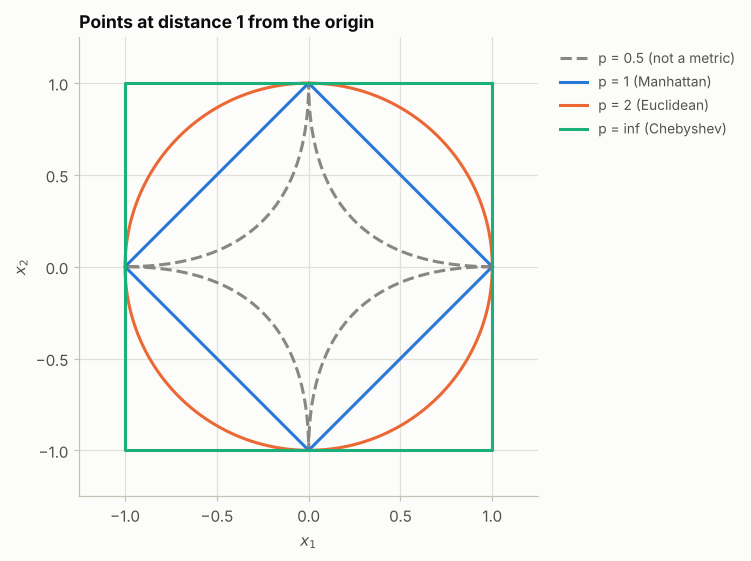

In [2]:
# EXTRA: Distances by hand, checked against scikit-learn -- and what the exponent p does
from sklearn.metrics import pairwise_distances

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 0.0, 3.5])
by_hand = {
    "euclidean (p=2)": np.sqrt(np.sum((a - b) ** 2)),
    "manhattan (p=1)": np.sum(np.abs(a - b)),
    "minkowski (p=3)": np.sum(np.abs(a - b) ** 3) ** (1 / 3),
    "chebyshev (p=inf)": np.max(np.abs(a - b)),
    "cosine": 1 - a @ b / (np.linalg.norm(a) * np.linalg.norm(b)),
}
by_sklearn = {
    "euclidean (p=2)": pairwise_distances([a], [b], metric="euclidean")[0, 0],
    "manhattan (p=1)": pairwise_distances([a], [b], metric="manhattan")[0, 0],
    "minkowski (p=3)": pairwise_distances([a], [b], metric="minkowski", p=3)[0, 0],
    "chebyshev (p=inf)": pairwise_distances([a], [b], metric="chebyshev")[0, 0],
    "cosine": pairwise_distances([a], [b], metric="cosine")[0, 0],
}
display(pd.DataFrame({"by hand": by_hand, "scikit-learn": by_sklearn}).round(4))

# One large difference versus many small ones: how much does each metric care?
many_small, one_big = np.ones(10), np.r_[10.0, np.zeros(9)]       # both differ from the origin
compare = pd.DataFrame({
    "10 coordinates differ by 1": [np.linalg.norm(many_small, ord=p) for p in (1, 2, np.inf)],
    "1 coordinate differs by 10": [np.linalg.norm(one_big, ord=p) for p in (1, 2, np.inf)],
}, index=["manhattan (p=1)", "euclidean (p=2)", "chebyshev (p=inf)"])
display(compare.round(2))

# p < 1 breaks the triangle inequality
d_half = lambda u, v: np.sum(np.abs(np.asarray(u) - np.asarray(v)) ** 0.5) ** 2
print("p = 0.5: d((0,0),(1,1)) =", d_half((0, 0), (1, 1)),
      "> d((0,0),(1,0)) + d((1,0),(1,1)) =", d_half((0, 0), (1, 0)) + d_half((1, 0), (1, 1)))

# Unit balls: all points at distance 1 from the origin
t = np.linspace(0, 2 * np.pi, 801)
fig, ax = plt.subplots(figsize=(7.4, 5.2))
for p, color, style, name in [(0.5, MUTED, "--", "p = 0.5 (not a metric)"), (1, PALETTE[0], "-", "p = 1 (Manhattan)"),
                               (2, PALETTE[1], "-", "p = 2 (Euclidean)"), (np.inf, PALETTE[2], "-", "p = inf (Chebyshev)")]:
    if np.isinf(p):
        xs, ys = np.array([1, -1, -1, 1, 1]), np.array([1, 1, -1, -1, 1])
    else:
        xs = np.sign(np.cos(t)) * np.abs(np.cos(t)) ** (2 / p)
        ys = np.sign(np.sin(t)) * np.abs(np.sin(t)) ** (2 / p)
    ax.plot(xs, ys, color=color, linestyle=style, label=name)
ax.set(aspect="equal", xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), xlabel="$x_1$", ylabel="$x_2$",
       title="Points at distance 1 from the origin")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
plt.tight_layout()
plt.show()

**Output analysis.**

* **By hand and by scikit-learn**, the five distances agree. For these two points:
  * Euclidean ≈ 3.64; Manhattan = 5.5;
  * Minkowski with $p = 3$ ≈ 3.275, between Euclidean and Chebyshev;
  * Chebyshev = 3, the largest single difference.

  As $p$ grows, the distance shrinks towards the largest coordinate difference.
* **One large difference versus many small ones:**
  * Manhattan rates both pairs as equally far (10).
  * Euclidean rates the single difference of 10 three times farther than ten differences of 1 (10 against 3.16).
  * Chebyshev sees only the single difference.

  This is the precise sense in which $L_1$ is "less sensitive to outliers": one extreme coordinate counts linearly instead of quadratically.
* **$p = 0.5$** gives a distance of 4 between opposite corners of the unit square but 2 along the two edges, violating the triangle inequality; its unit ball (dashed) is not convex. scikit-learn accepts $0 < p < 1$ only with a warning, and then falls back to brute-force search, because its tree indexes rely on the triangle inequality.
* **The unit balls** make the geometry visible: a diamond for $p = 1$, a circle for $p = 2$, a square for $p = \infty$. A KNN model with a given metric looks for neighbours inside these shapes, so the metric literally decides who counts as "near".

---
## 2. Understanding KNNs

### Summary

* KNN is a fundamental **supervised** technique for both classification and regression. The known points are placed in feature space, and a new point's characteristics are estimated from the existing points **nearest** to it, as measured by a distance metric. Qualitative measurements (colour, shape) and quantitative ones (length, width, height) can both describe the objects being compared.
* **Getting ready:** load the Iris dataset (150 flowers, 4 measurements, 3 species) and split it 80/20 with `random_state=2024` — by now a routine step.
* **How to do it:** create `KNeighborsClassifier(n_neighbors=3)`, fit it, predict the test set and print the accuracy: **0.9333** — "93% accuracy, which isn't a bad start".
* **How it works:** a new point gets the majority label of its $k$ nearest training neighbours.
  * **Choosing $k$:** a small $k$ is sensitive to noise; a large $k$ smooths the predictions but may overlook local patterns.
  * **Calculating distances:** Euclidean, Manhattan or another Minkowski distance; the choice can significantly affect the result.
  * **Voting:** majority vote for classification, the average of the neighbours' values for regression.

  Plotting decision boundaries for several values of $k$ shows how $k$ changes the classification.
* **There's more:**
  * Choose $k$ with cross-validation, or with the "elbow method": plot accuracy against $k$ and look for the point of diminishing returns.
  * Other metrics, such as Hamming distance for categorical data, can work better depending on the data. A decision diagram (Figure 4.1) helps pick the metric from the data's characteristics.
* **Hands-on exercises:** vary $k$, assess with accuracy or a confusion matrix, try other metrics, and plot decision boundaries that highlight misclassified points.

### Theory: the KNN rule

Let $N_k(\mathbf{x})$ be the $k$ training points closest to a new point $\mathbf{x}$ under the chosen metric.

* **Classification** predicts the class with the largest (weighted) vote:

$$\hat y(\mathbf{x}) = \arg\max_{c} \sum_{i \in N_k(\mathbf{x})} w_i\,\mathbb{1}[y_i = c], \qquad w_i = \begin{cases} 1 & \text{weights="uniform"} \\ 1 / d(\mathbf{x}, \mathbf{x}_i) & \text{weights="distance"} \end{cases}$$

  `predict_proba` returns the vote shares. With uniform weights they can only take the values $0, \tfrac1k, \tfrac2k, \dots, 1$.
* **Regression** (`KNeighborsRegressor`) predicts the (weighted) average $\hat y(\mathbf{x}) = \frac{1}{k}\sum_{i \in N_k(\mathbf{x})} y_i$.

**No training, expensive prediction.** KNN is a *lazy*, *non-parametric* learner. `fit` only stores the data, possibly in a KD-tree or ball tree; the work happens at prediction time:

* a brute-force search costs $O(nd)$ per query point ($n$ training points, $d$ features);
* tree indexes bring this close to $O(\log n)$ in low dimensions, but lose their advantage as $d$ grows (`algorithm="auto"` chooses).

**$k$ controls the bias–variance trade-off:**

| $k$ | Behaviour |
|---|---|
| $k = 1$ | Every training point is its own nearest neighbour, so training accuracy is (almost) 100%. The decision boundary follows the Voronoi cells of the training points: low bias, high variance. |
| larger $k$ | Smoother boundaries, less variance, more bias |
| $k = n$ | Every prediction is the majority class |

A useful guide is the number of points that vote: $n/k$ "effective parameters". For two classes, an odd $k$ avoids tied votes. scikit-learn breaks remaining ties in favour of the class that comes first in `classes_`.

**How good can KNN be?** Cover and Hart (1967) showed that, with infinitely many training points, the error of the 1-NN rule $R_{1\text{NN}}$ is at most twice the best possible (Bayes) error $R^*$. For two classes:

$$R^* \le R_{1\text{NN}} \le 2R^*(1 - R^*).$$

If $k$ grows with $n$ while $k/n \to 0$, the KNN rule approaches the Bayes error itself. In practice, data are finite and high-dimensional, so the choice of $k$, of the metric and of the feature scaling (Chapter 2) matters.

In [3]:
# BOOK CODE: Understanding KNNs -- getting ready (p. 71)
# Load libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

In [4]:
# BOOK CODE: Understanding KNNs -- how to do it (p. 72)
# Load libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create and train a basic KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


**Output analysis.**

* **The printed value is reproduced exactly:** `Accuracy: 0.9333333333333333`, as on p. 72. That is 28 of the 30 test flowers.
* **Two small precisions to the text:**
  * `iris.data` and `iris.target` are attributes, not methods (the text writes `.data()` and `.target()`).
  * The model does not use "the default arguments": `n_neighbors=3` is set explicitly, and the default is 5.
* **One split is a noisy judge.** With 30 test flowers, one flower is worth 3.3 percentage points of accuracy. The extras below use repeated cross-validation to judge $k$.

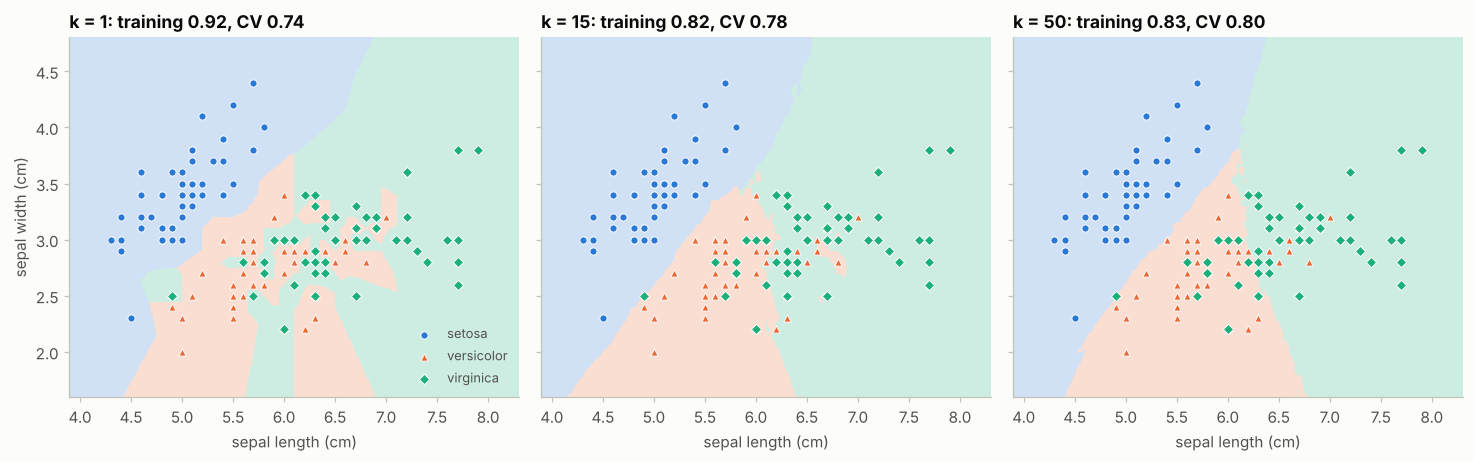

In [5]:
# EXTRA: (a) What k does to the decision boundary -- two iris features, so the regions can be drawn
from matplotlib.colors import ListedColormap
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

X_sepal = iris.data[:, :2]                        # sepal length and width: versicolor and virginica overlap here
y_iris = iris.target
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
grid_x, grid_y = np.meshgrid(np.linspace(X_sepal[:, 0].min() - 0.4, X_sepal[:, 0].max() + 0.4, 400),
                             np.linspace(X_sepal[:, 1].min() - 0.4, X_sepal[:, 1].max() + 0.4, 400))
regions = ListedColormap([lighten(c) for c in PALETTE])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), sharey=True)
for ax, k in zip(axes, [1, 15, 50]):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_sepal, y_iris)
    Z = model.predict(np.c_[grid_x.ravel(), grid_y.ravel()]).reshape(grid_x.shape)
    ax.pcolormesh(grid_x, grid_y, Z, cmap=regions, shading="auto")
    for cls, (color, marker) in enumerate(zip(PALETTE, ["o", "^", "D"])):
        m = y_iris == cls
        ax.scatter(X_sepal[m, 0], X_sepal[m, 1], s=22, color=color, marker=marker, edgecolor=SURFACE,
                   linewidth=0.6, label=iris.target_names[cls])
    cv_acc = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_sepal, y_iris, cv=rcv).mean()
    ax.set(title=f"k = {k}: training {model.score(X_sepal, y_iris):.2f}, CV {cv_acc:.2f}",
           xlabel="sepal length (cm)")
    ax.grid(False)
axes[0].set_ylabel("sepal width (cm)")
axes[0].legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.show()

k,1,3,5,7,9,11,15,21,25,31,41,51,61,75
training accuracy,1.000,0.960,0.967,0.973,0.980,0.973,0.987,0.980,0.980,0.960,0.953,0.953,0.933,0.907
CV accuracy (5 x 10 folds),0.956,0.961,0.967,0.966,0.965,0.971,0.970,0.958,0.951,0.948,0.948,0.926,0.899,0.882
std,0.037,0.033,0.030,0.033,0.033,0.031,0.032,0.035,0.038,0.036,0.039,0.034,0.044,0.046


default n_neighbors: 5 | test accuracy on the book's split with k=5: 0.9333


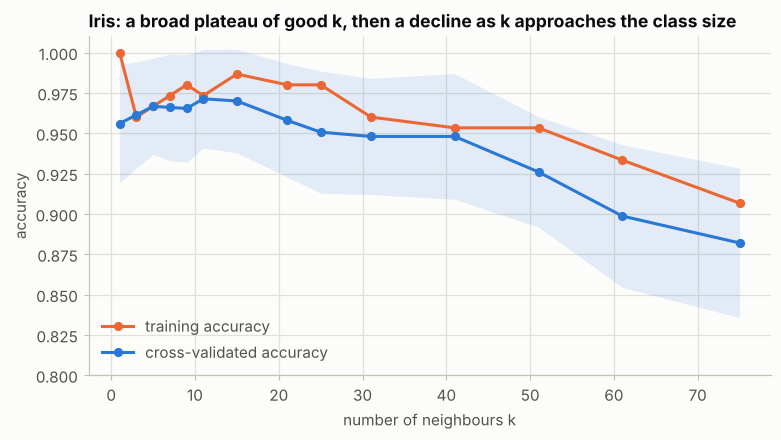

In [6]:
# EXTRA: (b) Choosing k -- repeated cross-validation on all four features (the "elbow" in numbers)
ks = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31, 41, 51, 61, 75]
rows = []
for k in ks:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), iris.data, iris.target, cv=rcv)
    train_acc = KNeighborsClassifier(n_neighbors=k).fit(iris.data, iris.target).score(iris.data, iris.target)
    rows.append((k, train_acc, scores.mean(), scores.std()))
k_curve = pd.DataFrame(rows, columns=["k", "training accuracy", "CV accuracy (5 x 10 folds)", "std"]).set_index("k")
display(k_curve.round(3).T)
print("default n_neighbors:", KNeighborsClassifier().n_neighbors,
      "| test accuracy on the book's split with k=5:",
      round(KNeighborsClassifier().fit(X_train, y_train).score(X_test, y_test), 4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_curve.index, k_curve.iloc[:, 0], color=PALETTE[1], marker="o", markersize=5, label="training accuracy")
ax.plot(k_curve.index, k_curve.iloc[:, 1], color=PALETTE[0], marker="o", markersize=5, label="cross-validated accuracy")
ax.fill_between(k_curve.index, k_curve.iloc[:, 1] - k_curve.iloc[:, 2], k_curve.iloc[:, 1] + k_curve.iloc[:, 2],
                color=PALETTE[0], alpha=0.12, linewidth=0)
ax.set(xlabel="number of neighbours k", ylabel="accuracy", ylim=(0.8, 1.01),
       title="Iris: a broad plateau of good k, then a decline as k approaches the class size")
ax.legend(loc="lower left")
plt.show()

k =  1: cross-validated MSE 0.155  (noise variance 0.09)
k = 10: cross-validated MSE 0.099  (noise variance 0.09)
k = 50: cross-validated MSE 0.173  (noise variance 0.09)


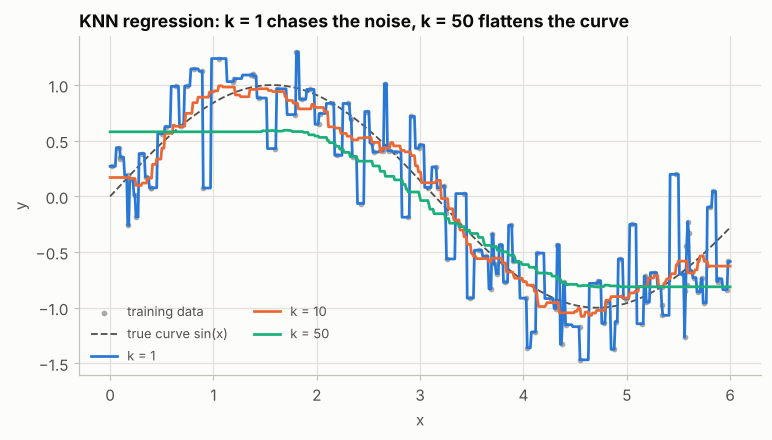

In [7]:
# EXTRA: (c) KNN regression -- the prediction is the average of the k nearest targets
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor

rng = np.random.default_rng(0)
x_reg = np.sort(rng.uniform(0, 6, 120))
y_reg = np.sin(x_reg) + rng.normal(0, 0.3, 120)          # a smooth curve plus noise
x_new = np.linspace(0, 6, 600)
kf = KFold(n_splits=5, shuffle=True, random_state=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_reg, y_reg, s=14, color=MUTED, alpha=0.7, linewidth=0, label="training data")
ax.plot(x_new, np.sin(x_new), color=INK_SOFT, linestyle="--", linewidth=1.2, label="true curve sin(x)")
for color, k in zip(PALETTE, [1, 10, 50]):
    reg = KNeighborsRegressor(n_neighbors=k).fit(x_reg.reshape(-1, 1), y_reg)
    mse = -cross_val_score(KNeighborsRegressor(n_neighbors=k), x_reg.reshape(-1, 1), y_reg, cv=kf,
                           scoring="neg_mean_squared_error").mean()
    print(f"k = {k:>2}: cross-validated MSE {mse:.3f}  (noise variance 0.09)")
    ax.plot(x_new, reg.predict(x_new.reshape(-1, 1)), color=color, linewidth=1.8, label=f"k = {k}")
ax.set(xlabel="x", ylabel="y", title="KNN regression: k = 1 chases the noise, k = 50 flattens the curve")
ax.legend(loc="lower left", fontsize=8.5, ncol=2)
plt.show()

**Output analysis.**

* **(a) Decision boundaries** (on the two sepal features only, where versicolor and virginica overlap heavily):
  * With $k = 1$ the boundary snakes around individual flowers and carves islands in the overlap. Training accuracy is the highest of the three (0.92), but the cross-validated accuracy is the lowest (0.74): the model memorizes noise. (Training accuracy is not 100% because a few flowers share identical sepal measurements but belong to different species.)
  * With $k = 15$ the regions are smooth (training 0.82, CV 0.78).
  * With $k = 50$ the boundaries are almost straight lines, and the cross-validated accuracy is the best of the three (0.80). On two features this noisy, heavy smoothing pays off.

  The gap between training and cross-validated accuracy shrinks from 0.18 to 0.03 as $k$ grows: less variance, more bias.
* **(b) Choosing $k$:**
  * Training accuracy is 1.0 at $k = 1$ by construction, since each flower is its own nearest neighbour. For larger $k$ it stays between 0.95 and 0.99 until $k$ approaches the class size.
  * The cross-validated accuracy forms a broad plateau of 0.96–0.97 from $k = 3$ to $k = 15$, then declines as $k$ approaches the class size (50 per species): 0.93 at $k = 51$, 0.88 at $k = 75$.
  * The plateau is the "elbow" region the book describes. Its differences are smaller than one standard deviation, so any $k$ on it is a reasonable choice.
  * The default $k = 5$ gives the same test accuracy as the book's $k = 3$ on the book's split.
* **(c) Regression:**
  * With $k = 1$ the curve passes through every training point and jumps with the noise.
  * With $k = 50$ (40% of the data) it flattens the peaks and troughs of the sine (bias).
  * $k = 10$ follows the curve closely, and its cross-validated error comes closest to the noise variance (0.09), the floor that no model can beat.

  This is the same trade-off as in classification, now visible as a curve.

---
## 3. Distance metrics overview

### Summary

* The choice of distance metric can significantly influence model performance — how points are classified and how clusters form. It is worth getting comfortable with more than the default Euclidean distance.
* **Getting ready** — two synthetic datasets:
  * **Noisy circles:** `make_circles(n_samples=300, noise=0.3, factor=0.3)`, where "Euclidean distance should work better".
  * **Checkerboard:** a $17 \times 17$ grid of points on $[0, 4]^2$, labelled by the parity of $\lfloor x \rfloor + \lfloor y \rfloor$, where "Manhattan distance should work better". It is stored in variables called `X_moons`; the name is arbitrary.

  Both are split 80/20. They are illustrative; real datasets rarely look like this.
* **How to do it:**
  * For each of `euclidean`, `manhattan` and `minkowski`, train a 3-NN classifier on both datasets and record the test accuracy.
  * Plot both datasets with the accuracies in the legend (Figure 4.2).
  * The book's reading: "Although possibly simply by luck in our Noisy Circles dataset, the Manhattan distance seems to provide the best estimation. We'd expect this behavior in the Checkerboard dataset, given that our data points are neatly arranged in a grid pattern."
* **How it works:**
  * **Euclidean** is the most common metric in KNN. It is sensitive to outliers and works best when the features are scaled similarly.
  * **Manhattan** ($L_1$, city block) sums absolute differences and is less sensitive to outliers.
  * **Minkowski** generalizes both: $p = 1$ is Manhattan, $p = 2$ is Euclidean.
* **Impact on model performance:**
  * *Sensitivity to scale* — standardize or normalize features before KNN.
  * *Dimensionality effects* — distances become less meaningful in high dimensions (Chapter 3).
* **There's more:** consider the nature of the data (continuous or categorical), experiment with several metrics, and compare them with cross-validation.
* **Hands-on exercises:** try `euclidean`, `manhattan`, `minkowski` and `cosine`, compare accuracies or confusion matrices, and visualize decision boundaries.

### Theory: choosing a metric

| Metric | Strength | Weakness |
|---|---|---|
| Euclidean ($p = 2$) | rotation-invariant; natural for continuous, comparably scaled features | dominated by the largest differences; needs scaling |
| Manhattan ($p = 1$) | one extreme coordinate counts linearly; often better in high dimensions (Aggarwal et al., 2001) | depends on the orientation of the axes |
| Chebyshev ($p = \infty$) | "worst single feature" logic | ignores all but one coordinate; many ties on grids |
| Cosine | compares directions; length-invariant | ignores magnitude; not a true metric |
| Hamming | binary or categorical codes | meaningless for continuous values |
| Mahalanobis | accounts for correlation and scale | needs a well-estimated covariance matrix |

**Three facts about the book's experiment:**

* **`metric="minkowski"` is Euclidean here.** scikit-learn's Minkowski metric uses `p=2` unless told otherwise, so the "Minkowski" column of Figure 4.2 is always identical to the "Euclidean" one. To test another member of the family, pass `p` explicitly, for example `KNeighborsClassifier(metric="minkowski", p=1.5)`.
* **The circles data change every run.** `make_circles` is called without `random_state`, so each run draws a different noisy dataset. This notebook fixes the global seed in the setup cell, so its numbers are reproducible but not the book's.
* **A grid creates ties.** On the checkerboard, every point has four neighbours at exactly the same distance (left, right, up, down, 0.25 away). With $k = 3$, which three of the four are used depends on the order of the training data, not on the metric. Many grid points also lie exactly on a square's edge, where the label is set by rounding down (`np.floor`).

In [8]:
# BOOK CODE: Distance metrics overview -- getting ready (pp. 75-76)
# Load libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create two synthetic datasets that highlight metric differences
n_samples = 300

# Circular dataset with high noise (Euclidean distance should work better)
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024
)

# Checkerboard pattern dataset (Manhattan distance should work better)
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024
)

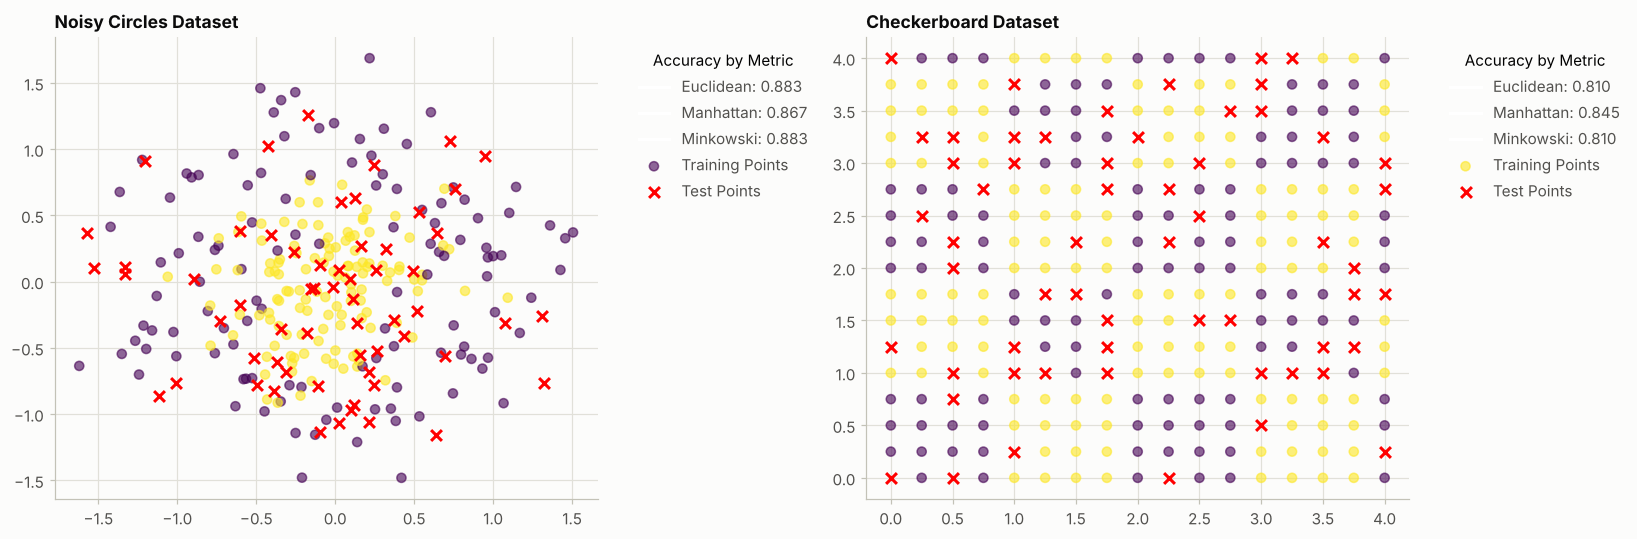

In [9]:
# BOOK CODE: Distance metrics overview -- how to do it (pp. 76-78)
# Compare different distance metrics on both datasets
metrics = ['euclidean', 'manhattan', 'minkowski']
results = {'circles': {}, 'moons': {}}

for metric in metrics:
    # Test on "circles" dataset
    knn_circles = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_circles.fit(X_circles_train, y_circles_train)
    y_pred_circles = knn_circles.predict(X_circles_test)
    results['circles'][metric] = accuracy_score(y_circles_test, y_pred_circles)

    # Test on "moons" dataset
    knn_moons = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_moons.fit(X_moons_train, y_moons_train)
    y_pred_moons = knn_moons.predict(X_moons_test)
    results['moons'][metric] = accuracy_score(y_moons_test, y_pred_moons)

# Set up plot specs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot circles dataset
scatter1_train = ax1.scatter(X_circles_train[:, 0], X_circles_train[:, 1], c=y_circles_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter1_test = ax1.scatter(X_circles_test[:, 0], X_circles_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax1.set_title('Noisy Circles Dataset')

# Create dummy lines for legend
lines1 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text1 = [
    f"Euclidean: {results['circles']['euclidean']:.3f}",
    f"Manhattan: {results['circles']['manhattan']:.3f}",
    f"Minkowski: {results['circles']['minkowski']:.3f}"
]
ax1.legend(lines1 + [scatter1_train, scatter1_test], legend_text1 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot moons dataset
scatter2_train = ax2.scatter(X_moons_train[:, 0], X_moons_train[:, 1], c=y_moons_train, cmap='viridis', alpha=0.6, label='Training Points')
scatter2_test = ax2.scatter(X_moons_test[:, 0], X_moons_test[:, 1], color='red', marker='x', s=50, label='Test Points')
ax2.set_title('Checkerboard Dataset')

# Create dummy lines for legend
lines2 = [plt.Line2D([0], [0], color='white') for _ in metrics]
legend_text2 = [
    f"Euclidean: {results['moons']['euclidean']:.3f}",
    f"Manhattan: {results['moons']['manhattan']:.3f}",
    f"Minkowski: {results['moons']['minkowski']:.3f}"
]
ax2.legend(lines2 + [scatter2_train, scatter2_test], legend_text2 + ['Training Points', 'Test Points'],
          title='Accuracy by Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Output analysis.**

* **Minkowski equals Euclidean** on both datasets, as explained above: the default `p=2` makes them the same metric.
* **This run's results** are printed in the figure's legends:
  * on the noisy circles, Euclidean is slightly *better* than Manhattan;
  * on the checkerboard, Manhattan is better.

  The book saw Manhattan win on both, "possibly simply by luck" on the circles — and luck it is. The circles are a new random draw in every run, and with 60 test points one point is worth 1.7 percentage points of accuracy. Extra (a) repeats the comparison on 50 datasets.
* **The checkerboard's points** sit on a regular grid with spacing 0.25. As the theory section explained, the outcome there depends on ties more than on the metric (extra b).
* **A naming pitfall in the listing.** `y = np.linspace(...)` reuses the name `y` and silently overwrites the iris labels from recipe 2. The later recipes only use `y_train` and `y_test`, so nothing breaks, but code that used `y` after this cell would. The extras use `iris.target` instead.

In [10]:
# EXTRA: (a) A fair comparison -- 50 random noisy-circle datasets, and repeated CV on the checkerboard
from sklearn.model_selection import StratifiedKFold

rows = []
for seed in range(50):
    X_s, y_s = make_circles(n_samples=300, noise=0.3, factor=0.3, random_state=seed)
    cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    rows.append([cross_val_score(KNeighborsClassifier(n_neighbors=3, metric=m), X_s, y_s, cv=cv_s).mean()
                 for m in ["euclidean", "manhattan"]])
circles_scores = np.array(rows)
diff = circles_scores[:, 1] - circles_scores[:, 0]
print(f"noisy circles, 50 datasets: Euclidean {circles_scores[:, 0].mean():.3f}, Manhattan {circles_scores[:, 1].mean():.3f}"
      f" | Manhattan better on {(diff > 0).sum()}, worse on {(diff < 0).sum()}, tied on {(diff == 0).sum()}")

checker_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
checker = pd.DataFrame(
    {m: cross_val_score(KNeighborsClassifier(n_neighbors=3, metric=m), X_moons, y_moons, cv=checker_cv)
     for m in ["euclidean", "manhattan", "chebyshev"]}).agg(["mean", "std"]).T
display(checker.round(3).rename(columns={"mean": "checkerboard CV accuracy (5 x 10 folds)"}))

noisy circles, 50 datasets: Euclidean 0.823, Manhattan 0.823 | Manhattan better on 25, worse on 22, tied on 3


,checkerboard CV accuracy (5 x 10 folds),std
euclidean,0.826,0.047
manhattan,0.834,0.046
chebyshev,0.680,0.055


In [11]:
# EXTRA: (b) Ties on the grid -- the order of the training rows changes the checkerboard result
from sklearn.neighbors import NearestNeighbors

for m in ["euclidean", "manhattan"]:
    dist, _ = NearestNeighbors(n_neighbors=4, metric=m).fit(X_moons_train).kneighbors(X_moons_test)
    print(f"{m:9s}: test points whose 3rd and 4th nearest neighbours are equally far: "
          f"{int(np.isclose(dist[:, 2], dist[:, 3]).sum())} of {len(X_moons_test)}")
on_edge = np.isclose(X_moons[:, 0] % 1, 0) | np.isclose(X_moons[:, 1] % 1, 0)
print(f"grid points lying exactly on the edge of a square: {int(on_edge.sum())} of {len(X_moons)}")

rng = np.random.default_rng(0)
order_effect = {m: [] for m in ["euclidean", "manhattan"]}
for _ in range(20):
    perm = rng.permutation(len(X_moons_train))            # same points, different row order
    for m in order_effect:
        model = KNeighborsClassifier(n_neighbors=3, metric=m).fit(X_moons_train[perm], y_moons_train[perm])
        order_effect[m].append(model.score(X_moons_test, y_moons_test))
for m, accs in order_effect.items():
    print(f"{m:9s}: test accuracy over 20 shufflings of the same training rows: {min(accs):.3f} to {max(accs):.3f}")

euclidean: test points whose 3rd and 4th nearest neighbours are equally far: 27 of 58
manhattan: test points whose 3rd and 4th nearest neighbours are equally far: 32 of 58
grid points lying exactly on the edge of a square: 145 of 289
euclidean: test accuracy over 20 shufflings of the same training rows: 0.741 to 0.845
manhattan: test accuracy over 20 shufflings of the same training rows: 0.759 to 0.879


In [12]:
# EXTRA: (c) Metrics on real data -- digit images (pixels on one scale) and breast-cancer measurements (standardized)
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

digits, cancer = load_digits(), load_breast_cancer()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
real = {}
for m in ["euclidean", "manhattan", "chebyshev", "cosine"]:
    real[m] = {
        "digits (64 pixels)": cross_val_score(KNeighborsClassifier(n_neighbors=5, metric=m),
                                              digits.data, digits.target, cv=cv5).mean(),
        "breast cancer (30 features, standardized)": cross_val_score(
            make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, metric=m)),
            cancer.data, cancer.target, cv=cv5).mean(),
    }
display(pd.DataFrame(real).T.round(4))

,digits (64 pixels),"breast cancer (30 features, standardized)"
euclidean,0.9855,0.9649
manhattan,0.9839,0.9666
chebyshev,0.9733,0.9420
cosine,0.9833,0.9666


**Output analysis.**

* **(a) No winner on the circles.** Over 50 random noisy-circle datasets, Euclidean and Manhattan reach the same average accuracy, and each wins on roughly half of the datasets. The book's single comparison measured noise. On the checkerboard, repeated cross-validation puts Manhattan slightly ahead of Euclidean, by less than one standard deviation. Chebyshev is clearly worse, because it also counts the diagonal neighbours as equally close.
* **(b) Ties decide the checkerboard:**
  * For about half of the test points, the 3rd and 4th nearest neighbours are equally far, so the 3-NN vote depends on which of the tied points comes first in the data.
  * Half of the grid points lie exactly on a square's edge.
  * Shuffling the order of the *same* training rows moves the test accuracy by about ten percentage points, more than the gap between the metrics.

  The checkerboard is a demonstration of ties, not of Manhattan's strengths.
* **(c) Real data:**
  * On the digit images, Euclidean, Manhattan and cosine are within a few tenths of a point of each other (about 0.98–0.99), and Chebyshev is lower: one pixel's largest difference is a poor summary of two images.
  * On the standardized breast-cancer data, the same pattern holds: Manhattan and cosine are marginally ahead of Euclidean, and Chebyshev trails.

  Metric choice is usually a second-order effect compared with **feature scaling** and $k$, but a "worst single feature" metric such as Chebyshev rarely suits many-featured data.

---
## 4. Hyperparameter tuning in KNN

### Summary

* Hyperparameter tuning is a critical step in optimizing a model.
  * **Parameters** are what a model learns during training — for a line $y = mx + b$, the slope $m$ and the intercept $b$.
  * **Hyperparameters** tell the model *how* to learn.

  The recipe announces two search techniques for finding the best ones.
* **Getting ready:** the Iris data again. The search covers the number of neighbours, whether to weight neighbours by their distance, and the distance metric.
* **How to do it:**
  * **Grid search** tests every combination of the given hyperparameter values and returns the best. Cross-validation, in the book's words, "is used to add an element of randomization" that makes the model robust.
  * `GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')` searches $k \in \{3, 5, 7, 9, 11\}$, `weights` in {uniform, distance} and `metric` in {euclidean, manhattan}.
  * The printed result: best parameters `{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}` with a cross-validation score of 0.9916666666666668.
* **How it works:** grid search is exhaustive; cross-validation evaluates the model on different subsets of the data, which helps prevent overfitting and gives a more reliable estimate.
* **Evaluating model performance:** fit the best parameters on the training set and check them on a separate test set, with accuracy for classifiers or mean squared error for regressors.
* **There's more:** `RandomizedSearchCV()` samples combinations from distributions instead of trying them all, which saves time in large search spaces.
* **Hands-on exercises:** search $k$ from 1 to 20 and several metrics, then print the best parameters and scores.

### Theory: what grid search estimates

* **KNN has hyperparameters but almost no parameters.** Its "parameters" are simply the stored training data. Everything that shapes its behaviour — $k$, the metric, the weighting — is a hyperparameter.
* **The cost of a grid.** The book's grid has $5 \times 2 \times 2 = 20$ candidates. With 5 folds that is 100 model fits, plus one final refit of the winner on all the training data (`refit=True`), which becomes `best_estimator_`.
* **What cross-validation does.** It does not add randomness: with an integer `cv` and a classifier, scikit-learn uses `StratifiedKFold` *without* shuffling, which is deterministic. Its purpose is to average the score over $K$ different held-out folds, which reduces the variance of the estimate compared with one split.
* **`weights="distance"`** weights each neighbour by $1/d$. A training point predicted by the model is its own neighbour at distance 0 and receives all the weight, so training accuracy is always 100% with distance weighting. Only cross-validated scores can compare it with uniform weights.
* **The winner's curse.** `best_score_` is the *maximum* of 20 noisy estimates, so it tends to be optimistic. An unbiased estimate of the whole procedure (search + refit) needs **nested cross-validation** (Varma & Simon, 2006): an outer loop splits the data, and the grid search runs inside each outer training set.
* **Ties.** Candidates with equal mean scores share a rank, and `best_params_` is the first of them in the order of `cv_results_`. On small datasets, where one sample changes the score by a whole step, ties are common.
* **Random search** (Bergstra & Bengio, 2012) draws `n_iter` candidates from distributions. If the best 5% of the search space counts as "good", 60 random draws contain at least one good candidate with probability $1 - 0.95^{60} \approx 0.95$, whatever the number of dimensions. This is why random search scales better than a grid when only a few hyperparameters matter.

In [13]:
# BOOK CODE: Hyperparameter tuning in KNN -- how to do it (pp. 81-82)
# Load libraries
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Create KNN classifier
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create grid search
grid_search = GridSearchCV(
    knn, param_grid, cv=5, scoring='accuracy'
)

# Fit grid search
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


**Output analysis.**

* **Both printed values are reproduced exactly:** the best parameters `{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}` and the cross-validation score `0.9916666666666668`, as on p. 82. The search is deterministic (no shuffling), so any scikit-learn version gives the same answer for the same split.
* A score of 0.9917 over 120 training flowers means a single misclassified flower across the five folds. Extra (a) shows how little separates the winner from the rest of the grid.

In [14]:
# EXTRA: (a) The whole grid -- how clear is the winner?
ranking = pd.DataFrame(grid_search.cv_results_)[["param_metric", "param_n_neighbors", "param_weights",
                                                   "mean_test_score", "std_test_score", "rank_test_score"]]
display(ranking.sort_values(["rank_test_score", "param_metric", "param_n_neighbors"]).head(10).round(4))
top = ranking["mean_test_score"].max()
print(f"candidates tied at the top score {top:.4f}: {(ranking['mean_test_score'] == top).sum()} of {len(ranking)}")
print(f"one flower in a fold of 24 is worth {1 / 24:.3f} of that fold's accuracy, and {1 / 120:.4f} of the mean")
print("training accuracy with weights='distance' (k=9):",
      KNeighborsClassifier(n_neighbors=9, weights="distance").fit(X_train, y_train).score(X_train, y_train))

,param_metric,param_n_neighbors,param_weights,mean_test_score,std_test_score,rank_test_score
6,euclidean,9,uniform,0.9917,0.0167,1
7,euclidean,9,distance,0.9917,0.0167,1
0,euclidean,3,uniform,0.9833,0.0204,3
1,euclidean,3,distance,0.9833,0.0204,3
2,euclidean,5,uniform,0.9833,0.0204,3
3,euclidean,5,distance,0.9833,0.0204,3
4,euclidean,7,uniform,0.9833,0.0204,3
5,euclidean,7,distance,0.9833,0.0204,3
8,euclidean,11,uniform,0.9833,0.0204,3
9,euclidean,11,distance,0.9833,0.0204,3


candidates tied at the top score 0.9917: 2 of 20
one flower in a fold of 24 is worth 0.042 of that fold's accuracy, and 0.0083 of the mean
training accuracy with weights='distance' (k=9): 1.0


In [15]:
# EXTRA: (b) Randomized search (the book's "There's more") over a wider space, including a continuous p
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": randint(1, 40), "weights": ["uniform", "distance"], "p": uniform(1, 2)},  # p in [1, 3]
    n_iter=30, cv=5, scoring="accuracy", random_state=0,
).fit(X_train, y_train)
best = random_search.best_params_
print(f"best of 30 random candidates: k={best['n_neighbors']}, weights={best['weights']}, p={best['p']:.2f} "
      f"| CV accuracy {random_search.best_score_:.4f}")
print(f"grid search: 20 candidates, best CV accuracy {grid_search.best_score_:.4f}")

best of 30 random candidates: k=5, weights=uniform, p=2.31 | CV accuracy 0.9833
grid search: 20 candidates, best CV accuracy 0.9917


In [16]:
# EXTRA: (c) How good is the tuned model really? best_score_, nested cross-validation and the test split
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)
nested = cross_val_score(GridSearchCV(KNeighborsClassifier(), param_grid, cv=inner_cv),
                         iris.data, iris.target, cv=outer_cv)
test_acc = grid_search.best_estimator_.score(X_test, y_test)
summary = pd.Series({
    "best_score_ of the book's search (inner CV on 120 training flowers)": grid_search.best_score_,
    "nested CV on all 150 flowers (search repeated inside each outer fold)": nested.mean(),
    "the book's 30-flower test split": test_acc,
}, name="accuracy")
display(summary.round(4).to_frame())
print(f"nested CV fold scores: {np.round(nested, 3)} | standard error of a 30-flower test accuracy: "
      f"{np.sqrt(test_acc * (1 - test_acc) / 30):.3f}")

,accuracy
best_score_ of the book's search (inner CV on 120 training flowers),0.9917
nested CV on all 150 flowers (search repeated inside each outer fold),0.9800
the book's 30-flower test split,0.9333


nested CV fold scores: [0.967 1.    1.    0.967 0.967] | standard error of a 30-flower test accuracy: 0.046


**Output analysis.**

* **(a) The winner is not clear-cut:**
  * Two candidates share the top score: $k = 9$ with uniform weights and with distance weights. The uniform one is reported because it comes first in `cv_results_`.
  * Below them, several candidates sit one step lower: a single extra misclassified flower in one fold.
  * With distance weighting, the training accuracy is exactly 1.0, as the theory predicts, so only the cross-validated score can judge it.

  On data this small, the grid search mostly reports which candidate was lucky on these folds. Any of the top candidates is a sound choice.
* **(b) Random search** samples 30 candidates from a wider space, including Minkowski exponents between 1 and 3, and reaches a CV accuracy just below the grid's best. On a space this small and a dataset this easy, the methods are equivalent. Random search pays off when the space is large and most dimensions do not matter.
* **(c) Three estimates of one model:**
  * The book's `best_score_` (0.99) is the maximum of 20 noisy scores.
  * The nested cross-validation estimate (about 0.98) evaluates the whole tuning procedure on data it never tuned on, and is the number to report.
  * The test split gives 0.93: just 2 errors among 30 flowers, with a standard error of about 0.05, so it is consistent with the other two.

---
## 5. Evaluating KNN performance

### Summary

* Evaluation shows how well a model predicts and where it needs improvement. The recipe covers confusion matrices, precision, recall and F1-scores.
* **Getting ready:** the Iris data and the tuned model from recipe 4, evaluated with cross-validation scores, learning curves and a confusion matrix. The printed listing loads `learning_curve`, `confusion_matrix` and seaborn.
* **How to do it:**
  1. Cross-validation scores of `grid_search.best_estimator_` on the training data.
  2. Learning curves with 10 training sizes from 10% to 100% (Figure 4.3).
  3. Predictions on the test set, and a confusion matrix drawn as a seaborn heatmap (Figure 4.4). The book reads it as "more correct predictions than incorrect ones based on the values along the diagonal".
  4. A classification report turned into a styled DataFrame with a blue gradient (Figure 4.5).
* **Two remarks in the text:**
  * One would normally be suspicious of 100% precision, recall and F1 (here for setosa), but this toy dataset is easy for any model.
  * In the real world, what counts as "very good" performance depends on the business problem.
* **Understanding evaluation metrics:**
  * **Learning curves** plot performance against the training-set size. They reveal under- or overfitting, and show when more data stops helping.
  * **The confusion matrix** counts true positives, true negatives, false positives and false negatives.
  * **The classification report** combines:
    * precision, the accuracy of positive predictions;
    * recall (sensitivity), the share of relevant instances found;
    * F1, the harmonic mean of precision and recall, useful for imbalanced data;
    * accuracy;
    * the macro average (plain mean over labels) and the weighted average (weighted by each label's number of examples).
* **There's more:** for **imbalanced datasets**, use precision-recall curves or ROC-AUC instead of accuracy alone, and consider resampling (oversampling the minority class or undersampling the majority class).
* **Hands-on exercises:** split, fit, predict, build a confusion matrix, compute precision, recall and F1, and plot the matrix.

### Theory: reading the numbers

For one class treated as "positive", count the test points in four cells: true positives (TP), false positives (FP), false negatives (FN) and true negatives (TN).

$$\text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = \frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision} + \text{recall}}, \qquad \text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}.$$

* **Multiclass reports** compute precision, recall and F1 once per class, treating that class as positive and all others as negative (one-vs-rest).
  * The **macro average** is their plain mean, so every class counts equally, however rare.
  * The **weighted average** weights each class by its *support* (its number of true samples).
  * For single-label problems the micro average equals the accuracy.
* **F1 is a harmonic mean**, so it is pulled towards the smaller of precision and recall: a model cannot hide a poor recall behind an excellent precision.
* **Learning curves** plot the training score and the validation score against the training-set size:

  | What the curves show | Diagnosis | Remedy |
  |---|---|---|
  | A large gap between training and validation | high variance (overfitting) | more data or a simpler model; for KNN, a larger $k$ |
  | Both curves low and close together | high bias (underfitting) | a more flexible model; for KNN, a smaller $k$ or better features |
  | The validation curve has flattened | more data will not help much | change the model, not the data |

* **Imbalanced classes:**
  * With 95% negatives, predicting "negative" always gives 95% accuracy — the *accuracy paradox*.
  * **Balanced accuracy** (the mean recall over classes) and the precision–recall curve with its **average precision** focus on the minority class. ROC-AUC measures ranking quality but can look optimistic when negatives dominate (Saito & Rehmsmeier, 2015).
  * KNN's `predict_proba` gives vote shares, so the decision threshold can be moved below 0.5 to trade precision for recall.

In [17]:
# BOOK CODE: Evaluating KNN performance -- getting ready (p. 84; the import line from the official notebook,
# which also loads cross_val_score, classification_report and pandas used below)
# Load libraries
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


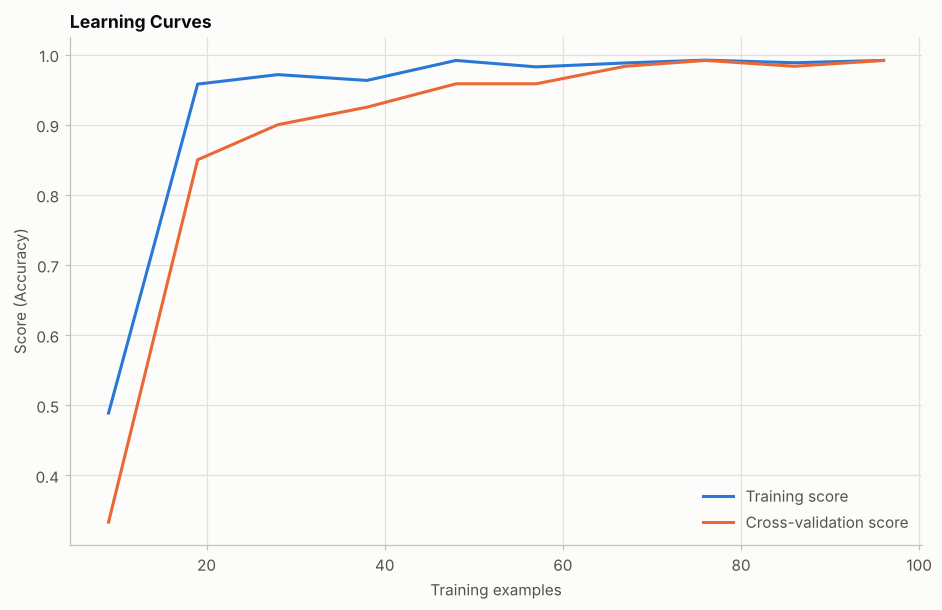

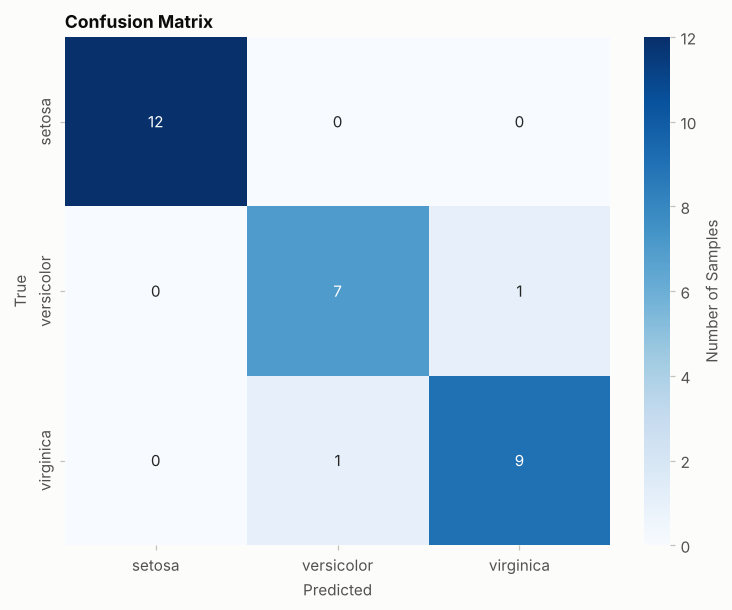


Classification Report:


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


In [18]:
# BOOK CODE: Evaluating KNN performance -- how to do it (pp. 84-87)
# Get cross-validation scores
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score (Accuracy)')
plt.legend(loc='best')
plt.title('Learning Curves')
plt.show()

# Make predictions on test set
y_pred = grid_search.best_estimator_.predict(X_test)

# Get class names from iris dataset
class_names = iris.target_names

# Generate and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Get classification report as a dict
report_dict = classification_report(y_test, y_pred,
                                  target_names=class_names,
                                  output_dict=True)

# Create a DataFrame for better visualization
report_df = pd.DataFrame(report_dict).transpose()

# Style the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print("\nClassification Report:")
display(styled_df)

**Output analysis.**

* **The cross-validation scores** are 0.958 for one fold and 1.0 for the other four: mean 0.9917, standard deviation 0.0167. These are *exactly* the scores behind `best_score_` in recipe 4. `cross_val_score` with `cv=5` uses the same unshuffled folds as the grid search, so this step re-measures the winner on the folds that selected it rather than adding new evidence.
* **The learning curve:**
  * The first point, with 9 training flowers, is at 0.33. With $k = 9$ and only 9 training points, all of them vote on every prediction, so the model always predicts the majority class: chance level for three classes.
  * By about 50 flowers the cross-validated accuracy reaches about 0.96, and from about 76 flowers it is close to the training score (about 0.99).

  The curves have converged with a small gap, so more data would add little. This matches the official notebook's comment that the model "doesn't improve much after ~50 training examples".
* **The confusion matrix:**
  * all 12 setosa flowers are correct;
  * 7 of 8 versicolor (one taken for virginica);
  * 9 of 10 virginica (one taken for versicolor).

  The two errors are between the two species whose measurements overlap. Setosa is linearly separable from both, which is why its 100% scores are not suspicious.
* **The classification report:**
  * Precision, recall and F1 are 1.00 for setosa, 0.875 for versicolor and 0.90 for virginica.
  * The macro averages are about 0.925, and the accuracy is 0.933 — the same test accuracy as the untuned $k = 3$ model of recipe 2. On this split, tuning changed nothing measurable.
  * The styled table appears with its colour gradient in Jupyter. Renderers that strip styles, such as GitHub's, show the plain table.

In [19]:
# EXTRA: (a) Every number of the report, computed from the confusion matrix
rows = {}
for i, name in enumerate(class_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp          # predicted as this class, but belonging to another
    fn = cm[i, :].sum() - tp          # belonging to this class, but predicted as another
    precision, recall = tp / (tp + fp), tp / (tp + fn)
    rows[name] = {"TP": tp, "FP": fp, "FN": fn, "precision": precision, "recall": recall,
                  "f1-score": 2 * precision * recall / (precision + recall), "support": cm[i, :].sum()}
by_hand = pd.DataFrame(rows).T.astype(float)
support = by_hand["support"].astype(float)
by_hand.loc["macro avg", ["precision", "recall", "f1-score"]] = by_hand.loc[class_names, ["precision", "recall", "f1-score"]].mean()
by_hand.loc["weighted avg", ["precision", "recall", "f1-score"]] = (
    by_hand.loc[class_names, ["precision", "recall", "f1-score"]].mul(support, axis=0).sum() / support.sum())
display(by_hand.astype(float).round(3))
print("accuracy = trace / total =", round(np.trace(cm) / cm.sum(), 4))
print("matches classification_report:",
      np.allclose(by_hand.loc[report_df.index[[0, 1, 2, 4, 5]], ["precision", "recall", "f1-score"]].astype(float),
                  report_df.loc[report_df.index[[0, 1, 2, 4, 5]], ["precision", "recall", "f1-score"]]))

,TP,FP,FN,precision,recall,f1-score,support
setosa,12.0,0.0,0.0,1.000,1.000,1.000,12.0
versicolor,7.0,1.0,1.0,0.875,0.875,0.875,8.0
virginica,9.0,1.0,1.0,0.900,0.900,0.900,10.0
macro avg,NaN,NaN,NaN,0.925,0.925,0.925,NaN
weighted avg,NaN,NaN,NaN,0.933,0.933,0.933,NaN


accuracy = trace / total = 0.9333
matches classification_report: True


In [20]:
# EXTRA: (b) KNN on imbalanced data -- the accuracy paradox, better metrics, and moving the threshold
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, balanced_accuracy_score, recall_score, roc_auc_score

X_imb, y_imb = make_classification(n_samples=4000, n_features=10, n_informative=4, weights=[0.95, 0.05],
                                   flip_y=0, class_sep=0.8, random_state=0)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=0)
knn_imb = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)).fit(Xi_train, yi_train)
proba = knn_imb.predict_proba(Xi_test)[:, 1]                    # share of the 15 neighbours in the minority class

rows = []
for name, pred in [("always predict the majority (dummy)", DummyClassifier().fit(Xi_train, yi_train).predict(Xi_test)),
                   ("KNN, threshold 0.5 (predict)", (proba >= 0.5).astype(int)),
                   ("KNN, threshold 0.2", (proba >= 0.2).astype(int))]:
    rows.append((name, accuracy_score(yi_test, pred), balanced_accuracy_score(yi_test, pred), recall_score(yi_test, pred)))
display(pd.DataFrame(rows, columns=["model", "accuracy", "balanced accuracy", "minority recall"]).set_index("model").round(3))
print(f"minority share: {y_imb.mean():.1%} | KNN ranking quality: ROC-AUC {roc_auc_score(yi_test, proba):.3f}, "
      f"average precision {average_precision_score(yi_test, proba):.3f} (a random ranking scores {yi_test.mean():.3f})")
print("distinct probability values KNN can output with k=15:", np.unique(proba).size)

,accuracy,balanced accuracy,minority recall
model,,,
always predict the majority (dummy),0.950,0.500,0.00
"KNN, threshold 0.5 (predict)",0.961,0.610,0.22
"KNN, threshold 0.2",0.962,0.753,0.52


minority share: 5.0% | KNN ranking quality: ROC-AUC 0.884, average precision 0.595 (a random ranking scores 0.050)
distinct probability values KNN can output with k=15: 13


**Output analysis.**

* **(a) By hand.** From the confusion matrix alone, the per-class TP, FP and FN give exactly the precision, recall, F1, macro and weighted averages of `classification_report`, and the accuracy is the diagonal sum over the total. Versicolor and virginica each have one false positive and one false negative — the two swapped flowers.
* **(b) Imbalanced data:**
  * With 5% positives, a dummy model that always answers "negative" already scores 95% accuracy. KNN scores only about one point higher while finding barely a fifth of the minority class.
  * Balanced accuracy and minority recall expose the problem; accuracy hides it.
  * The ranking is decent: the ROC-AUC is well above 0.5, and the average precision is many times the 5% a random ranking would get. The default threshold is simply wrong for a rare class: lowering the vote threshold from 0.5 to 0.2 more than doubles the minority recall, and raises the balanced accuracy, without losing any accuracy.
  * KNN's probabilities are coarse (at most $k + 1$ distinct values), which limits how finely the threshold can be tuned.

  This is the practical content of the book's "There's more" on imbalanced datasets.

---
## 6. Practical exercises with KNN models

### Summary

* The final recipe builds, tunes and evaluates KNN models on further datasets, reinforcing the chapter's concepts.
  * **Exercise 1: building a KNN classifier.** Use a dataset of your choice, ideally one that needs preprocessing, to connect with Chapter 2. Steps: load the libraries, load the dataset, preprocess, create and train the classifier, predict, evaluate.
  * **Exercise 2: tuning hyperparameters with grid search.** Load a different dataset, preprocess it, set up and fit a grid search, and evaluate the best model.
  * **Exercise 3: evaluating a KNN classifier.** The same six steps as exercise 1, with the evaluation techniques of recipe 5.
* **There's more:**
  * Use distance metrics for other tasks, such as clustering and regression.
  * Explore DBSCAN, mean shift, spectral clustering, kernel density estimation and the radius neighbors classifier, all available in scikit-learn.

> The book lists only the steps. The code below is the **official solution** from the chapter's exercise notebook in the book's repository. Its datasets:
> * exercise 1: the breast-cancer data, with standardization;
> * exercises 2 and 3: synthetic data from `make_classification`.

### Theory: the tools used in the exercises

* **Scaling without leakage.** The solutions fit `StandardScaler` on the training split only and apply it to the test split — the rule of Chapter 2. A `Pipeline` does the same automatically and is required as soon as cross-validation enters (extra a).
* **`make_classification`** builds Gaussian clusters around the vertices of a hypercube:
  * `n_informative` dimensions carry the signal;
  * `n_redundant` features are random linear combinations of them;
  * the remaining features are noise;
  * `n_clusters_per_class` sets how many clusters form each class.

  With 20 features of which 15 are informative and 3 classes, exercise 2 is much harder for KNN than Iris.
* **Other neighbour-based classifiers**, from the book's "There's more":
  * `RadiusNeighborsClassifier` votes among all training points within a fixed radius $r$ instead of a fixed number $k$. Its neighbourhoods adapt to the density, but points in sparse regions may have no neighbours at all (`outlier_label` decides what happens then).
  * `NearestCentroid` replaces each class by its mean and assigns the nearest one. It is extremely fast, with a linear decision boundary between each pair of classes.

In [21]:
# BOOK CODE: Exercise 1 -- building a KNN classifier (p. 90; official solution from the book's repository)
# Load libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load the Dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Preprocess the Data
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.947

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [22]:
# BOOK CODE: Exercise 2 -- tuning hyperparameters with grid search (p. 90; official solution from the book's repository)
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load a different dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                         n_redundant=5, n_classes=3, random_state=42)

# Preprocess the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up grid search:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Evaluate best model
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
y_pred = grid_search.predict(X_test_scaled)
print("\nTest Set Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.8574999999999999

Test Set Performance:
Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        70
           1       0.91      0.96      0.93        73
           2       0.79      0.81      0.80        57

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.88       200



In [23]:
# BOOK CODE: Exercise 3 -- evaluating a KNN classifier (p. 90; official solution from the book's repository)
# Load libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Dataset
# Create a synthetic dataset with 3 classes and some informative/redundant features
X, y = make_classification(n_samples=1000,
                         n_features=15,
                         n_informative=10,
                         n_redundant=5,
                         n_classes=3,
                         n_clusters_per_class=2,
                         random_state=42)

# Preprocess the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and Train the KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluate Performance
print("Model Performance Evaluation")
print("-" * 30)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Performance Evaluation
------------------------------
Accuracy Score: 0.850

Confusion Matrix:
[[56  6  6]
 [ 4 56  5]
 [ 6  3 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        68
           1       0.86      0.86      0.86        65
           2       0.84      0.87      0.85        67

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200



**Output analysis.**

* **Exercise 1** (breast cancer, 114 test patients). The scaled 5-NN classifier reaches about 0.95 accuracy. Malignant tumours (class 0) are found with slightly lower recall than benign ones, and missing a malignant tumour is the costlier error, so recall on class 0 deserves the attention here.
* **Exercise 2** (synthetic, 3 classes, 20 features):
  * The grid search picks the same combination as on Iris (Euclidean, $k = 9$, uniform), with a cross-validated accuracy of about 0.86.
  * The test accuracy is 0.88. Close to the CV estimate, so the search did not overfit noticeably.
  * The task is harder than Iris because the classes are spread over 15 informative dimensions and the remaining features add redundancy.
* **Exercise 3** (synthetic, 3 classes, 2 clusters per class) reaches 0.85 accuracy. The confusion matrix and the report show errors spread over all three classes. Each class is made of two separate clusters, which is exactly the kind of structure a local method such as KNN can follow, but 15 dimensions make the neighbourhoods less informative (Chapter 3's curse of dimensionality).

In [24]:
# EXTRA: (a) Exercise 1 without scaling -- and why one split is not enough to tell
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=42)
rows = []
for name, model in [("with StandardScaler (the solution)", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),
                    ("without scaling", KNeighborsClassifier(n_neighbors=5))]:
    split_acc = model.fit(Xc_train, yc_train).score(Xc_test, yc_test)
    cv_scores = cross_val_score(model, cancer.data, cancer.target, cv=cv5)
    rows.append((name, split_acc, cv_scores.mean(), cv_scores.std()))
display(pd.DataFrame(rows, columns=["model", "the solution's test split", "5-fold CV accuracy", "std"]).set_index("model").round(3))
print("feature scales (std) range from", round(cancer.data.std(axis=0).min(), 4), "to", round(cancer.data.std(axis=0).max(), 1))

,the solution's test split,5-fold CV accuracy,std
model,,,
with StandardScaler (the solution),0.947,0.965,0.021
without scaling,0.956,0.932,0.019


feature scales (std) range from 0.0026 to 568.9


In [25]:
# EXTRA: (b) Other neighbour-based classifiers from the book's "There's more" (breast cancer, standardized, 5-fold CV)
from sklearn.neighbors import NearestCentroid, RadiusNeighborsClassifier

family = {
    "KNeighborsClassifier (k=5)": KNeighborsClassifier(n_neighbors=5),
    "RadiusNeighborsClassifier (r=4)": RadiusNeighborsClassifier(radius=4.0, outlier_label="most_frequent"),
    "RadiusNeighborsClassifier (r=5)": RadiusNeighborsClassifier(radius=5.0, outlier_label="most_frequent"),
    "NearestCentroid": NearestCentroid(),
}
display(pd.Series({name: cross_val_score(make_pipeline(StandardScaler(), est), cancer.data, cancer.target, cv=cv5).mean()
                   for name, est in family.items()}, name="5-fold CV accuracy").round(4).to_frame())
Z_cancer = StandardScaler().fit_transform(cancer.data)
counts = np.array([len(idx) - 1 for idx in
                   NearestNeighbors(radius=4.0).fit(Z_cancer).radius_neighbors(Z_cancer, return_distance=False)])
print(f"other patients within radius 4 in the standardized 30-D space: median {np.median(counts):.0f}, "
      f"10th percentile {np.percentile(counts, 10):.0f}, 90th percentile {np.percentile(counts, 90):.0f}, "
      f"patients with none: {(counts == 0).sum()}")

,5-fold CV accuracy
KNeighborsClassifier (k=5),0.9649
RadiusNeighborsClassifier (r=4),0.9034
RadiusNeighborsClassifier (r=5),0.9051
NearestCentroid,0.9315


other patients within radius 4 in the standardized 30-D space: median 73, 10th percentile 1, 90th percentile 199, patients with none: 39


**Output analysis.**

* **(a) Scaling and the single split:**
  * On the solution's split, the *unscaled* model happens to score slightly higher than the scaled one, which would suggest that scaling does not matter.
  * Five-fold cross-validation says the opposite: scaling raises the accuracy by more than three points. The 30 features have standard deviations from about 0.003 to over 500, so without scaling the distances are dominated by the area-type features.
  * A 114-patient test split is too small to compare two pipelines reliably — the same lesson as in recipe 4.
* **(b) The neighbour family:**
  * $k$-NN is the most accurate of the four.
  * The radius classifiers are clearly weaker. With radius 4, a typical patient has dozens of other patients inside the radius, a patient in a dense region about two hundred, and dozens of patients none at all. A single radius is too large for the dense regions, where it averages over very many points (like a huge $k$), and too small for the sparse ones, where the "most frequent" fallback label takes over.
  * `NearestCentroid` is respectable for a model that stores only two mean vectors: one distance computation per class instead of a search through all training points.

  Fixed-count neighbourhoods adapt to the density automatically, which is why `KNeighborsClassifier` is the default choice.

---
## Decision guide: choosing a distance for KNN

The book's Figure 4.1 is a decision diagram for choosing a metric from the data's characteristics. The table below is this notebook's own summary of the same question, based on the theory and the experiments above.

| Data | Metric | Notes |
|---|---|---|
| Continuous features on comparable scales | Euclidean (`metric="minkowski", p=2`, the default) | standardize first; try Manhattan as well |
| Many features, or one extreme feature should not dominate | Manhattan (`p=1`) | often better in high dimensions |
| Direction matters, magnitude does not (text, embeddings) | cosine (`metric="cosine"`) | needs brute-force search |
| Binary or categorical codes | Hamming (`metric="hamming"`) | one-hot features with Euclidean distance also work |
| Correlated features on different scales | Mahalanobis (`metric="mahalanobis"`, `metric_params={"VI": inverse_covariance}`) | or whiten the data, then use Euclidean |
| Mixed types | separate preprocessing per column (Chapter 2) | no single built-in metric fits |

Whatever the metric, choose $k$ and compare metrics with cross-validation, with the scaler inside a `Pipeline`.

## Chapter summary and key takeaways

| Recipe | Main tools | Key idea |
|---|---|---|
| Introduction to distance metrics | `pairwise_distances` | A metric obeys four axioms; the Minkowski exponent $p$ decides how much the largest difference dominates |
| Understanding KNNs | `KNeighborsClassifier`, `KNeighborsRegressor` | Vote (or average) over the $k$ nearest points; $k$ trades variance against bias |
| Distance metrics overview | `metric`, `p` | Metric choice matters less than scaling and $k$; compare metrics on many datasets, not one split |
| Hyperparameter tuning | `GridSearchCV`, `RandomizedSearchCV` | `best_score_` is optimistic; nested cross-validation estimates the tuned model honestly |
| Evaluating performance | `cross_val_score`, `learning_curve`, `confusion_matrix`, `classification_report` | Every report number follows from the confusion matrix; with imbalance, use balanced metrics and move the threshold |
| Practical exercises | `StandardScaler`, `make_classification`, `RadiusNeighborsClassifier`, `NearestCentroid` | Scale inside the evaluation, and judge with cross-validation |

**Key takeaways**

1. KNN has no training step and almost no parameters: its behaviour is set by $k$, the metric, the weighting — and the scale of the features.
2. Small $k$ means low bias and high variance; large $k$ the opposite. Choose $k$ by cross-validation; a broad plateau of good values is normal.
3. The Minkowski exponent controls how much one large coordinate difference dominates. Euclidean and Manhattan rarely differ much on real data, while scaling changes everything.
4. On tiny datasets, grid-search winners are often ties, and single test splits are noisy. Report nested cross-validation.
5. Accuracy is misleading on imbalanced data. Look at recall, balanced accuracy and precision–recall, and tune the decision threshold.

**Book (scikit-learn 1.5) vs. the version used here — notes from the reproduction**

* All listings and the three official exercise solutions run unchanged on scikit-learn 1.9.1. The printed outputs are reproduced exactly:
  * `Accuracy: 0.9333333333333333` (p. 72);
  * the grid search's best parameters `{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}` with a score of `0.9916666666666668` (p. 82).
* Figure 4.2 cannot be reproduced number for number, because `make_circles` is called without `random_state`. Its "Minkowski" results always equal the Euclidean ones, because `metric="minkowski"` defaults to `p=2`.
* The evaluation listing on p. 84 uses `cross_val_score`, `classification_report` and pandas without importing them. The import cell above follows the official notebook, which loads them. Seaborn is needed for the heatmap.
* Small precisions to the chapter text:
  * The chapter's opening list mentions a recipe "Model implementation in scikit-learn" that has no section of its own; the implementation is part of "Understanding KNNs".
  * `iris.data` and `iris.target` are attributes, not methods.
  * The first model uses `n_neighbors=3`, not the default 5.
  * Cross-validation averages over deterministic folds; it does not "add randomization".
  * The checkerboard comparison is decided by distance ties more than by the metric.
  * The checkerboard listing overwrites the iris labels `y` with a grid axis.

## References

1. Sukup, J. (2025). *scikit-learn Cookbook* (3rd ed.). Packt Publishing. Code repository: <https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition>
2. Fix, E., & Hodges, J. L. (1951). *Discriminatory analysis. Nonparametric discrimination: consistency properties* (Report No. 4). USAF School of Aviation Medicine, Randolph Field, Texas.
3. Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory, 13*(1), 21–27.
4. Mahalanobis, P. C. (1936). On the generalized distance in statistics. *Proceedings of the National Institute of Sciences of India, 2*(1), 49–55.
5. Aggarwal, C. C., Hinneburg, A., & Keim, D. A. (2001). On the surprising behavior of distance metrics in high dimensional space. In *Database Theory — ICDT 2001* (pp. 420–434). Springer.
6. Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281–305.
7. Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics, 7*, 91.
8. Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432.
9. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
10. scikit-learn documentation: [Nearest neighbors](https://scikit-learn.org/stable/modules/neighbors.html) · [Pairwise metrics](https://scikit-learn.org/stable/modules/metrics.html) · [Tuning the hyper-parameters of an estimator](https://scikit-learn.org/stable/modules/grid_search.html) · [Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html) · [Learning curves](https://scikit-learn.org/stable/modules/learning_curve.html)